# Train 128-D Word Embeddings from Scratch
- For 50 Epochs
- This notebook loads the corpus and tokenization outputs saved by the previous notebook in Google Drive. It manually implements embedding lookup with `nn.Parameter`, pretrains English and Bangla embeddings using skip-gram negative sampling, and saves reusable checkpoints to Drive.

## Imports

In [1]:
import json
import math
import random
from dataclasses import asdict, dataclass
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


## Mount Google Drive

Connects Colab to Google Drive, where the saved corpus, tokenizer outputs, and trained embeddings are stored.

In [2]:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Reproducibility and configuration

128 dimensions and defines the Drive paths and skip-gram training settings.

In [3]:
@dataclass
class EmbeddingConfig:
    drive_root: str = "/content/drive/MyDrive/Transformer"
    corpus_filename: str = "en_bn_parallel_corpus_2k.tsv"
    tokenized_folder: str = "tokenized_data"
    embedding_folder: str = "trained_embeddings"
    embedding_dimension: int = 128

    context_window: int = 2
    negative_samples: int = 5
    batch_size: int = 512
    learning_rate: float = 0.003
    epochs: int = 50
    random_seed: int = 42
    minimum_normal_token_id: int = 4


config = EmbeddingConfig()

if config.embedding_dimension not in {64, 128}:
    raise ValueError("embedding_dimension must be either 64 or 128.")

random.seed(config.random_seed)
torch.manual_seed(config.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive_root = Path(config.drive_root)
corpus_path = drive_root / config.corpus_filename
tokenized_dir = drive_root / config.tokenized_folder
output_dir = drive_root / config.embedding_folder / f"{config.embedding_dimension}d"
output_dir.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Embedding dimension:", config.embedding_dimension)
print("Corpus:", corpus_path)
print("Tokenized input:", tokenized_dir)
print("Model output:", output_dir)


Device: cuda
Embedding dimension: 128
Corpus: /content/drive/MyDrive/Transformer/en_bn_parallel_corpus_2k.tsv
Tokenized input: /content/drive/MyDrive/Transformer/tokenized_data
Model output: /content/drive/MyDrive/Transformer/trained_embeddings/128d


## Validate Drive inputs

Confirms that the original corpus, both tokenizer vocabularies, and the tokenized training split exist before training begins.

In [4]:
required_paths = {
    "original corpus": corpus_path,
    "English tokenizer": tokenized_dir / "english_tokenizer.json",
    "Bangla tokenizer": tokenized_dir / "bangla_tokenizer.json",
    "tokenized training split": tokenized_dir / "train_tokenized.jsonl",
}

missing = [name for name, path in required_paths.items() if not path.exists()]

if missing:
    missing_text = ", ".join(missing)
    raise FileNotFoundError(
        f"Missing Drive files: {missing_text}. Run the tokenization notebook first "
        "and place the corpus at MyDrive/Transformer/en_bn_parallel_corpus_2k.tsv."
    )

print("All required Drive files were found.")


All required Drive files were found.


## Load and verify the original corpus

Reads the Drive-saved TSV corpus and checks its required columns and split sizes.

In [5]:
corpus = pd.read_csv(corpus_path, sep="\t")
required_columns = {"split", "en", "bn"}
missing_columns = required_columns - set(corpus.columns)

if missing_columns:
    raise ValueError(f"Corpus is missing columns: {sorted(missing_columns)}")

if corpus[["en", "bn"]].isna().any().any():
    raise ValueError("The corpus contains missing English or Bangla sentences.")

print("Corpus rows:", len(corpus))
print(corpus["split"].value_counts())
corpus.head()


Corpus rows: 2000
split
train         1800
validation     100
test           100
Name: count, dtype: int64


,split,en,bn
0,train,There is a hall in the window.,হলে একটি জানালা আছে।
1,train,Please wait for the teacher this morning.,দয়া করে আজ সকালে শিক্ষকের জন্য অপেক্ষা করুন।
2,train,"after class, the family listens to music.",ক্লাসের পরে পরিবারটি গান শোনে।
3,train,The programmer uses the computer to solve a pr...,প্রোগ্রামার কম্পিউটার ব্যবহার করে একটি সমস্যা ...
4,train,Where can I buy a notebook in this village?,আমি এই গ্রামে একটি খাতা কোথায় কিনতে পারি?


## Loading saved vocabularies and tokenized sentences


In [6]:
def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def load_jsonl(path):
    records = []
    with Path(path).open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as error:
                    raise ValueError(
                        f"Invalid JSON on line {line_number} of {path}"
                    ) from error
    return records


english_tokenizer_data = load_json(
    tokenized_dir / "english_tokenizer.json"
)
bangla_tokenizer_data = load_json(
    tokenized_dir / "bangla_tokenizer.json"
)
tokenized_training_records = load_jsonl(
    tokenized_dir / "train_tokenized.jsonl"
)

english_id_to_token = english_tokenizer_data["id_to_token"]
bangla_id_to_token = bangla_tokenizer_data["id_to_token"]

english_token_to_id = {
    token: index for index, token in enumerate(english_id_to_token)
}
bangla_token_to_id = {
    token: index for index, token in enumerate(bangla_id_to_token)
}

english_vocabulary_size = len(english_id_to_token)
bangla_vocabulary_size = len(bangla_id_to_token)

print("Tokenized training rows:", len(tokenized_training_records))
print("English vocabulary:", english_vocabulary_size)
print("Bangla vocabulary:", bangla_vocabulary_size)


Tokenized training rows: 1800
English vocabulary: 449
Bangla vocabulary: 479


## Integrity checks

Verifies that the tokenized training rows match the Drive-saved training corpus and that every ID fits its vocabulary.

In [7]:
training_corpus = corpus[corpus["split"] == "train"].reset_index(drop=True)

if len(training_corpus) != len(tokenized_training_records):
    raise ValueError(
        "The original training corpus and tokenized training file have different sizes."
    )

for row_index, (corpus_row, tokenized_row) in enumerate(
    zip(training_corpus.to_dict("records"), tokenized_training_records)
):
    if str(corpus_row["en"]) != str(tokenized_row["source_text"]):
        raise ValueError(f"English text mismatch at training row {row_index}.")
    if str(corpus_row["bn"]) != str(tokenized_row["target_text"]):
        raise ValueError(f"Bangla text mismatch at training row {row_index}.")

    if not all(0 <= token_id < english_vocabulary_size for token_id in tokenized_row["source_ids"]):
        raise ValueError(f"Invalid English token ID at row {row_index}.")
    if not all(0 <= token_id < bangla_vocabulary_size for token_id in tokenized_row["target_ids"]):
        raise ValueError(f"Invalid Bangla token ID at row {row_index}.")

print("Corpus/tokenization integrity checks passed.")


Corpus/tokenization integrity checks passed.


## Build skip-gram training pairs

Creates positive `(center token, nearby token)` pairs while excluding PAD, UNK, BOS, and EOS.

In [8]:
class SkipGramPairDataset(Dataset):
    def __init__(self, sequences, context_window=2, minimum_token_id=4):
        self.pairs = []

        for sequence in sequences:
            normal_tokens = [
                int(token_id)
                for token_id in sequence
                if int(token_id) >= minimum_token_id
            ]

            for center_position, center_id in enumerate(normal_tokens):
                left = max(0, center_position - context_window)
                right = min(len(normal_tokens), center_position + context_window + 1)

                for context_position in range(left, right):
                    if context_position != center_position:
                        self.pairs.append(
                            (center_id, normal_tokens[context_position])
                        )

        if not self.pairs:
            raise ValueError("No skip-gram pairs could be created.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        center_id, context_id = self.pairs[index]
        return (
            torch.tensor(center_id, dtype=torch.long),
            torch.tensor(context_id, dtype=torch.long),
        )


english_sequences = [
    record["source_ids"] for record in tokenized_training_records
]
bangla_sequences = [
    record["target_ids"] for record in tokenized_training_records
]

english_pair_dataset = SkipGramPairDataset(
    english_sequences,
    context_window=config.context_window,
    minimum_token_id=config.minimum_normal_token_id,
)
bangla_pair_dataset = SkipGramPairDataset(
    bangla_sequences,
    context_window=config.context_window,
    minimum_token_id=config.minimum_normal_token_id,
)

print("English positive pairs:", len(english_pair_dataset))
print("Bangla positive pairs:", len(bangla_pair_dataset))


English positive pairs: 48648
Bangla positive pairs: 38424


## Creating DataLoaders

Shuffles and batches the positive skip-gram pairs for optimization.

In [9]:
data_generator = torch.Generator()
data_generator.manual_seed(config.random_seed)

english_pair_loader = DataLoader(
    english_pair_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    generator=data_generator,
)
bangla_pair_loader = DataLoader(
    bangla_pair_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    generator=data_generator,
)

print("English batches per epoch:", len(english_pair_loader))
print("Bangla batches per epoch:", len(bangla_pair_loader))


English batches per epoch: 96
Bangla batches per epoch: 76


## Manual embedding layer

embedding lookup directly with a learnable `nn.Parameter` matrix instead of `nn.Embedding`.

In [10]:
class ManualEmbedding(nn.Module):
    def __init__(self, vocabulary_size, embedding_dimension, padding_id=0):
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.embedding_dimension = embedding_dimension
        self.padding_id = padding_id
        self.weight = nn.Parameter(
            torch.empty(vocabulary_size, embedding_dimension)
        )
        self.reset_parameters()

    def reset_parameters(self):
        bound = 0.5 / self.embedding_dimension
        nn.init.uniform_(self.weight, -bound, bound)
        with torch.no_grad():
            self.weight[self.padding_id].zero_()

    def forward(self, token_ids):
        return self.weight[token_ids]


## Skip-gram negative-sampling model

Raises scores for real neighboring tokens and lowers scores for randomly sampled incorrect tokens.

In [11]:
class SkipGramNegativeSampling(nn.Module):
    def __init__(
        self,
        vocabulary_size,
        embedding_dimension,
        negative_samples=5,
        minimum_token_id=4,
    ):
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.negative_samples = negative_samples
        self.minimum_token_id = minimum_token_id

        self.input_embeddings = ManualEmbedding(
            vocabulary_size,
            embedding_dimension,
            padding_id=0,
        )
        self.output_embeddings = ManualEmbedding(
            vocabulary_size,
            embedding_dimension,
            padding_id=0,
        )

    def sample_negative_ids(self, positive_context_ids):
        shape = (
            positive_context_ids.shape[0],
            self.negative_samples,
        )
        negative_ids = torch.randint(
            low=self.minimum_token_id,
            high=self.vocabulary_size,
            size=shape,
            device=positive_context_ids.device,
        )

        collisions = negative_ids.eq(positive_context_ids.unsqueeze(1))
        while collisions.any():
            replacement_count = int(collisions.sum().item())
            negative_ids[collisions] = torch.randint(
                low=self.minimum_token_id,
                high=self.vocabulary_size,
                size=(replacement_count,),
                device=positive_context_ids.device,
            )
            collisions = negative_ids.eq(positive_context_ids.unsqueeze(1))

        return negative_ids

    def forward(self, center_ids, positive_context_ids):
        center_vectors = self.input_embeddings(center_ids)
        positive_vectors = self.output_embeddings(positive_context_ids)

        positive_scores = torch.sum(
            center_vectors * positive_vectors,
            dim=1,
        )

        negative_ids = self.sample_negative_ids(positive_context_ids)
        negative_vectors = self.output_embeddings(negative_ids)
        negative_scores = torch.bmm(
            negative_vectors,
            center_vectors.unsqueeze(2),
        ).squeeze(2)

        positive_log_likelihood = F.logsigmoid(positive_scores)
        negative_log_likelihood = F.logsigmoid(-negative_scores).sum(dim=1)

        return -(
            positive_log_likelihood + negative_log_likelihood
        ).mean()

    def embedding_matrix(self):
        return self.input_embeddings.weight.detach()


## Cell 12 — Trainer class

Optimizes one embedding model, records epoch losses, and keeps the zero-padding row fixed.

In [12]:
class EmbeddingTrainer:
    def __init__(self, model, dataloader, learning_rate, device):
        self.model = model.to(device)
        self.dataloader = dataloader
        self.device = device
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=learning_rate,
        )
        self.loss_history = []

    def fit(self, epochs):
        for epoch in range(1, epochs + 1):
            self.model.train()
            total_loss = 0.0
            total_examples = 0

            for center_ids, context_ids in self.dataloader:
                center_ids = center_ids.to(self.device)
                context_ids = context_ids.to(self.device)

                self.optimizer.zero_grad(set_to_none=True)
                loss = self.model(center_ids, context_ids)
                loss.backward()
                self.optimizer.step()

                with torch.no_grad():
                    self.model.input_embeddings.weight[0].zero_()
                    self.model.output_embeddings.weight[0].zero_()

                batch_size = center_ids.shape[0]
                total_loss += loss.item() * batch_size
                total_examples += batch_size

            epoch_loss = total_loss / total_examples
            self.loss_history.append(epoch_loss)
            print(
                f"Epoch {epoch:02d}/{epochs} | loss: {epoch_loss:.4f}"
            )

        return self.loss_history


## Cell 13 — Initialize English and Bangla models

Creates two independent models because English and Bangla have different vocabularies.

In [13]:
english_model = SkipGramNegativeSampling(
    vocabulary_size=english_vocabulary_size,
    embedding_dimension=config.embedding_dimension,
    negative_samples=config.negative_samples,
    minimum_token_id=config.minimum_normal_token_id,
)
bangla_model = SkipGramNegativeSampling(
    vocabulary_size=bangla_vocabulary_size,
    embedding_dimension=config.embedding_dimension,
    negative_samples=config.negative_samples,
    minimum_token_id=config.minimum_normal_token_id,
)

english_trainer = EmbeddingTrainer(
    english_model,
    english_pair_loader,
    config.learning_rate,
    device,
)
bangla_trainer = EmbeddingTrainer(
    bangla_model,
    bangla_pair_loader,
    config.learning_rate,
    device,
)

print(english_model)
print(bangla_model)


SkipGramNegativeSampling(
  (input_embeddings): ManualEmbedding()
  (output_embeddings): ManualEmbedding()
)
SkipGramNegativeSampling(
  (input_embeddings): ManualEmbedding()
  (output_embeddings): ManualEmbedding()
)


## Cell 14 — Train both embedding models

Fits the English and Bangla matrices using only the Drive-saved tokenized training split.

In [14]:
print("Training English embeddings")
english_loss_history = english_trainer.fit(config.epochs)

print("\nTraining Bangla embeddings")
bangla_loss_history = bangla_trainer.fit(config.epochs)


Training English embeddings
Epoch 01/50 | loss: 2.6547
Epoch 02/50 | loss: 1.8052
Epoch 03/50 | loss: 1.5783
Epoch 04/50 | loss: 1.3324
Epoch 05/50 | loss: 1.1426
Epoch 06/50 | loss: 1.0135
Epoch 07/50 | loss: 0.9364
Epoch 08/50 | loss: 0.8824
Epoch 09/50 | loss: 0.8547
Epoch 10/50 | loss: 0.8321
Epoch 11/50 | loss: 0.8251
Epoch 12/50 | loss: 0.8065
Epoch 13/50 | loss: 0.8005
Epoch 14/50 | loss: 0.7963
Epoch 15/50 | loss: 0.7901
Epoch 16/50 | loss: 0.7801
Epoch 17/50 | loss: 0.7898
Epoch 18/50 | loss: 0.7774
Epoch 19/50 | loss: 0.7673
Epoch 20/50 | loss: 0.7746
Epoch 21/50 | loss: 0.7689
Epoch 22/50 | loss: 0.7705
Epoch 23/50 | loss: 0.7762
Epoch 24/50 | loss: 0.7732
Epoch 25/50 | loss: 0.7706
Epoch 26/50 | loss: 0.7724
Epoch 27/50 | loss: 0.7684
Epoch 28/50 | loss: 0.7647
Epoch 29/50 | loss: 0.7604
Epoch 30/50 | loss: 0.7641
Epoch 31/50 | loss: 0.7726
Epoch 32/50 | loss: 0.7645
Epoch 33/50 | loss: 0.7658
Epoch 34/50 | loss: 0.7661
Epoch 35/50 | loss: 0.7584
Epoch 36/50 | loss: 0.7617


## Cell 15 — Plot training losses

Checks whether the skip-gram objective is improving during training.

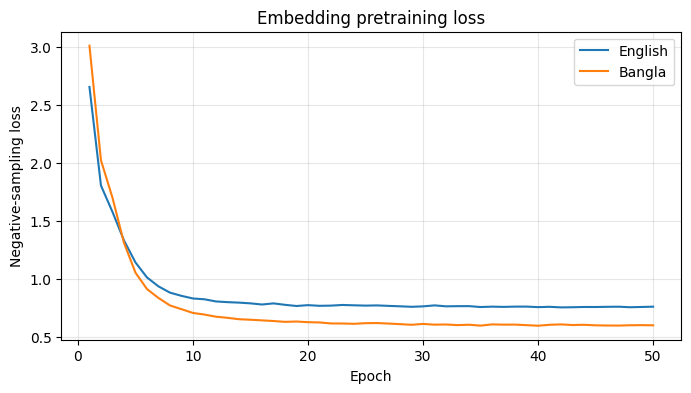

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, config.epochs + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, english_loss_history, label="English")
plt.plot(epochs, bangla_loss_history, label="Bangla")
plt.xlabel("Epoch")
plt.ylabel("Negative-sampling loss")
plt.title("Embedding pretraining loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Cell 16 — Save trained checkpoints to Drive

Stores model weights, vocabularies, configuration, losses, and standalone embedding matrices for later Transformer initialization.

In [16]:
def save_embedding_checkpoint(
    model,
    id_to_token,
    loss_history,
    language,
    save_path,
):
    checkpoint = {
        "language": language,
        "embedding_dimension": config.embedding_dimension,
        "vocabulary_size": len(id_to_token),
        "id_to_token": id_to_token,
        "config": asdict(config),
        "loss_history": loss_history,
        "model_state_dict": model.state_dict(),
        "embedding_matrix": model.embedding_matrix().cpu(),
    }
    torch.save(checkpoint, save_path)
    print("Saved:", save_path)


english_checkpoint_path = output_dir / "english_embedding_model.pt"
bangla_checkpoint_path = output_dir / "bangla_embedding_model.pt"

save_embedding_checkpoint(
    english_model,
    english_id_to_token,
    english_loss_history,
    "English",
    english_checkpoint_path,
)
save_embedding_checkpoint(
    bangla_model,
    bangla_id_to_token,
    bangla_loss_history,
    "Bangla",
    bangla_checkpoint_path,
)

torch.save(
    english_model.embedding_matrix().cpu(),
    output_dir / "english_embedding_matrix.pt",
)
torch.save(
    bangla_model.embedding_matrix().cpu(),
    output_dir / "bangla_embedding_matrix.pt",
)


Saved: /content/drive/MyDrive/Transformer/trained_embeddings/128d/english_embedding_model.pt
Saved: /content/drive/MyDrive/Transformer/trained_embeddings/128d/bangla_embedding_model.pt


## Cell 17 — Reload and validate checkpoints

Loads the saved files from Drive and confirms the expected vocabulary and embedding dimensions.

In [17]:
english_checkpoint = torch.load(
    english_checkpoint_path,
    map_location="cpu",
    weights_only=False,
)
bangla_checkpoint = torch.load(
    bangla_checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

expected_english_shape = (
    english_vocabulary_size,
    config.embedding_dimension,
)
expected_bangla_shape = (
    bangla_vocabulary_size,
    config.embedding_dimension,
)

assert tuple(english_checkpoint["embedding_matrix"].shape) == expected_english_shape
assert tuple(bangla_checkpoint["embedding_matrix"].shape) == expected_bangla_shape

print("English matrix:", tuple(english_checkpoint["embedding_matrix"].shape))
print("Bangla matrix:", tuple(bangla_checkpoint["embedding_matrix"].shape))
print("Checkpoint validation passed.")

English matrix: (449, 128)
Bangla matrix: (479, 128)
Checkpoint validation passed.


## Cell 18 — Inspect nearest tokens

Uses cosine similarity to inspect which learned token vectors are closest to a selected word.

In [18]:
def nearest_tokens(
    query_token,
    token_to_id,
    id_to_token,
    embedding_matrix,
    top_k=5,
    minimum_token_id=4,
):
    if query_token not in token_to_id:
        raise KeyError(f"Token not found: {query_token}")

    query_id = token_to_id[query_token]
    normalized = F.normalize(embedding_matrix.float(), p=2, dim=1)
    similarities = normalized @ normalized[query_id]
    similarities[:minimum_token_id] = -float("inf")
    similarities[query_id] = -float("inf")

    nearest_ids = torch.topk(
        similarities,
        k=min(top_k, len(id_to_token) - minimum_token_id - 1),
    ).indices.tolist()

    return [
        (id_to_token[token_id], float(similarities[token_id]))
        for token_id in nearest_ids
    ]


english_query = "student"
bangla_query = "শিক্ষার্থী"

print(
    english_query,
    nearest_tokens(
        english_query,
        english_token_to_id,
        english_id_to_token,
        english_checkpoint["embedding_matrix"],
    ),
)
print(
    bangla_query,
    nearest_tokens(
        bangla_query,
        bangla_token_to_id,
        bangla_id_to_token,
        bangla_checkpoint["embedding_matrix"],
    ),
)

student [('farmer', 0.6597926616668701), ('mina', 0.6201171278953552), ('rina', 0.6196253895759583), ('karim', 0.618000328540802), ('rahim', 0.5945395827293396)]
শিক্ষার্থী [('শিক্ষক', 0.6448277235031128), ('রহিম', 0.6109583973884583), ('খুলেছে', 0.6043280363082886), ('মিনা', 0.6005430817604065), ('করিম', 0.5983290076255798)]


## Cell 19 — Use the embeddings in the Transformer

Shows how to copy the saved matrices into your later source and target embedding layers.

In [19]:
class TransformerTokenEmbedding(nn.Module):
    def __init__(self, pretrained_matrix, padding_id=0):
        super().__init__()
        self.embedding_dimension = pretrained_matrix.shape[1]
        self.padding_id = padding_id
        self.weight = nn.Parameter(pretrained_matrix.clone())

    def forward(self, token_ids):
        vectors = self.weight[token_ids]
        return vectors * math.sqrt(self.embedding_dimension)


source_embedding = TransformerTokenEmbedding(
    english_checkpoint["embedding_matrix"]
)
target_embedding = TransformerTokenEmbedding(
    bangla_checkpoint["embedding_matrix"]
)

sample_source_ids = torch.tensor(
    tokenized_training_records[0]["source_ids"],
    dtype=torch.long,
).unsqueeze(0)
sample_source_vectors = source_embedding(sample_source_ids)

print("Token-ID shape:", tuple(sample_source_ids.shape))
print("Embedding shape:", tuple(sample_source_vectors.shape))

Token-ID shape: (1, 10)
Embedding shape: (1, 10, 128)


## Drive Output Folder

In [20]:
from pathlib import Path

EMBEDDING_SAVE_DIR = Path(
    "/content/drive/MyDrive/Transformer/trained_embeddings"
)

EMBEDDING_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Save directory:", EMBEDDING_SAVE_DIR)

Save directory: /content/drive/MyDrive/Transformer/trained_embeddings


In [21]:
english_loss_history = english_trainer.fit(config.epochs)

Epoch 01/50 | loss: 0.7634
Epoch 02/50 | loss: 0.7621
Epoch 03/50 | loss: 0.7603
Epoch 04/50 | loss: 0.7605
Epoch 05/50 | loss: 0.7673
Epoch 06/50 | loss: 0.7602
Epoch 07/50 | loss: 0.7607
Epoch 08/50 | loss: 0.7627
Epoch 09/50 | loss: 0.7654
Epoch 10/50 | loss: 0.7615
Epoch 11/50 | loss: 0.7661
Epoch 12/50 | loss: 0.7574
Epoch 13/50 | loss: 0.7590
Epoch 14/50 | loss: 0.7619
Epoch 15/50 | loss: 0.7557
Epoch 16/50 | loss: 0.7592
Epoch 17/50 | loss: 0.7584
Epoch 18/50 | loss: 0.7578
Epoch 19/50 | loss: 0.7619
Epoch 20/50 | loss: 0.7583
Epoch 21/50 | loss: 0.7549
Epoch 22/50 | loss: 0.7550
Epoch 23/50 | loss: 0.7534
Epoch 24/50 | loss: 0.7623
Epoch 25/50 | loss: 0.7592
Epoch 26/50 | loss: 0.7589
Epoch 27/50 | loss: 0.7628
Epoch 28/50 | loss: 0.7568
Epoch 29/50 | loss: 0.7615
Epoch 30/50 | loss: 0.7615
Epoch 31/50 | loss: 0.7608
Epoch 32/50 | loss: 0.7627
Epoch 33/50 | loss: 0.7565
Epoch 34/50 | loss: 0.7683
Epoch 35/50 | loss: 0.7594
Epoch 36/50 | loss: 0.7582
Epoch 37/50 | loss: 0.7569
E

In [22]:
english_embedding_matrix = (
    english_trainer.model
    .input_embeddings
    .weight
    .detach()
    .cpu()
)

english_embedding_path = (
    EMBEDDING_SAVE_DIR
    / "english_embedding_matrix.pt"
)

torch.save(
    english_embedding_matrix,
    english_embedding_path
)

print(
    "English embeddings saved:",
    english_embedding_path
)

print(
    "Shape:",
    english_embedding_matrix.shape
)

English embeddings saved: /content/drive/MyDrive/Transformer/trained_embeddings/english_embedding_matrix.pt
Shape: torch.Size([449, 128])


## Bangla Embedding

In [23]:
bangla_loss_history = bangla_trainer.fit(config.epochs)

Epoch 01/50 | loss: 0.6043
Epoch 02/50 | loss: 0.5991
Epoch 03/50 | loss: 0.6001
Epoch 04/50 | loss: 0.5983
Epoch 05/50 | loss: 0.6003
Epoch 06/50 | loss: 0.6044
Epoch 07/50 | loss: 0.6001
Epoch 08/50 | loss: 0.5973
Epoch 09/50 | loss: 0.6050
Epoch 10/50 | loss: 0.5965
Epoch 11/50 | loss: 0.6038
Epoch 12/50 | loss: 0.6098
Epoch 13/50 | loss: 0.6055
Epoch 14/50 | loss: 0.5988
Epoch 15/50 | loss: 0.5925
Epoch 16/50 | loss: 0.5981
Epoch 17/50 | loss: 0.5970
Epoch 18/50 | loss: 0.6033
Epoch 19/50 | loss: 0.5997
Epoch 20/50 | loss: 0.6064
Epoch 21/50 | loss: 0.6001
Epoch 22/50 | loss: 0.5966
Epoch 23/50 | loss: 0.6029
Epoch 24/50 | loss: 0.5953
Epoch 25/50 | loss: 0.5985
Epoch 26/50 | loss: 0.5989
Epoch 27/50 | loss: 0.6044
Epoch 28/50 | loss: 0.5925
Epoch 29/50 | loss: 0.6016
Epoch 30/50 | loss: 0.6022
Epoch 31/50 | loss: 0.5978
Epoch 32/50 | loss: 0.5970
Epoch 33/50 | loss: 0.6056
Epoch 34/50 | loss: 0.5964
Epoch 35/50 | loss: 0.6029
Epoch 36/50 | loss: 0.5938
Epoch 37/50 | loss: 0.5967
E

In [24]:
bangla_embedding_matrix = (
    bangla_trainer.model
    .input_embeddings
    .weight
    .detach()
    .cpu()
)

bangla_embedding_path = (
    EMBEDDING_SAVE_DIR
    / "bangla_embedding_matrix.pt"
)

torch.save(
    bangla_embedding_matrix,
    bangla_embedding_path
)

print(
    "Bangla embeddings saved:",
    bangla_embedding_path
)

print(
    "Shape:",
    bangla_embedding_matrix.shape
)

Bangla embeddings saved: /content/drive/MyDrive/Transformer/trained_embeddings/bangla_embedding_matrix.pt
Shape: torch.Size([479, 128])


# Save Training Checkpoint

In [25]:
torch.save(
    {
        "model_state_dict":
            english_trainer.model.state_dict(),

        "optimizer_state_dict":
            english_trainer.optimizer.state_dict(),

        "loss_history":
            english_loss_history,

        "embedding_dimension":
            config.embedding_dimension,

        "vocabulary_size":
            english_vocabulary_size,
    },

    EMBEDDING_SAVE_DIR
    / "english_embedding_checkpoint.pt"
)


torch.save(
    {
        "model_state_dict":
            bangla_trainer.model.state_dict(),

        "optimizer_state_dict":
            bangla_trainer.optimizer.state_dict(),

        "loss_history":
            bangla_loss_history,

        "embedding_dimension":
            config.embedding_dimension,

        "vocabulary_size":
            bangla_vocabulary_size,
    },

    EMBEDDING_SAVE_DIR
    / "bangla_embedding_checkpoint.pt"
)


print("Full checkpoints saved.")

Full checkpoints saved.


## Verify Saved Files

In [26]:
saved_files = [
    "english_embedding_matrix.pt",
    "bangla_embedding_matrix.pt",
    "english_embedding_checkpoint.pt",
    "bangla_embedding_checkpoint.pt",
]


for filename in saved_files:

    path = (
        EMBEDDING_SAVE_DIR
        / filename
    )

    print(
        filename,
        "found" if path.exists() else "Not Found"
    )

english_embedding_matrix.pt found
bangla_embedding_matrix.pt found
english_embedding_checkpoint.pt found
bangla_embedding_checkpoint.pt found
